# Access CAREHeat
    * Original Data Source:
        https://zenodo.org/records/8154587 - not processed
        https://data-cersat.ifremer.fr/data/marine-heat-wave/esa-careheat/cnr/v2/
        https://sextant.ifremer.fr/record/87a33c31-5930-4379-8cfa-0b29ceee9756/
    * Reference:  https://opensciencedata.esa.int/projects/careheat/collection
    * OSC entry: https://opensciencedata.esa.int/projects/careheat/collection
    * License: cc-by-4.0.

In [1]:
import xarray as xr

In [3]:
ds = xr.open_zarr('https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/ocean_datasets/careheat_mhw_2d.zarr/')
ds

<xarray.Dataset> Size: 68GB
Dimensions:   (time: 16437, lat: 720, lon: 1440)
Coordinates:
  * time      (time) datetime64[ns] 131kB 1980-01-01 1980-01-02 ... 2024-12-31
  * lat       (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon       (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    category  (time, lat, lon) float32 68GB dask.array<chunksize=(30, 720, 1440), meta=np.ndarray>
Attributes: (12/16)
    contact:            federico.serva@terrarum.eu
    author:             Federico Serva
    institution:        CNR-ISMAR
    version:            v2025a
    date:               2025-08
    website:            https://careheat.org/
    ...                 ...
    climatologyPeriod:  [1991, 2020]
    windowHalfWidth:    5
    pctile:             90
    minDuration:        5
    maxGap:             2
    NCO:                netCDF Operators version 4.8.1 (Homepage = http://nco...

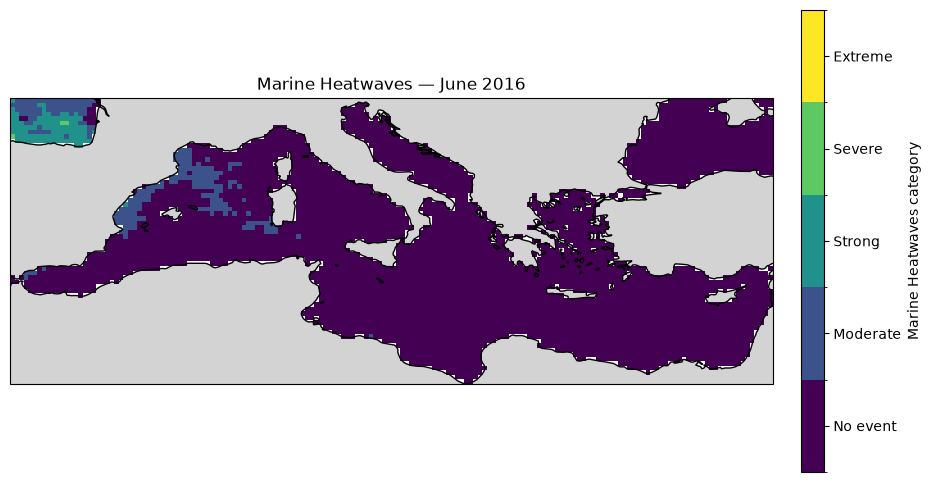

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
import numpy as np

date = "2020-06"


da = ds["category"].sel(time=np.datetime64(date), lon=slice(-6.062, 36.06), lat=slice(30.27, 45.98), drop=True)

# Categories present in the data
categories = [0, 1, 2, 3, 4]

# Discrete colormap
cmap = plt.get_cmap("viridis", len(categories))

# Put colour boundaries halfway between categories
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

im = ax.pcolormesh(
    da.lon,
    da.lat,
    da,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    shading="auto"
)

ax.coastlines()
ax.add_feature(cfeature.LAND, facecolor="lightgray")



labels = [
    "No event",
    "Moderate",
    "Strong",
    "Severe",
    "Extreme"
]

cbar = fig.colorbar(
    im,
    ax=ax,
    ticks=[0, 1, 2, 3, 4],
    pad=0.03
)

cbar.ax.set_yticklabels(labels)
cbar.set_label("Marine Heatwaves category")

ax.set_title("Marine Heatwaves - June 2016")

plt.show()